In [1]:
%%capture
%pip install qldpc
%pip install matplotlib
%pip install tqec

## Decoding TQEC circuits

[TQEC](https://github.com/tqec/tqec) compiles lattice surgery operations into physical circuits that implement the corresponding logical operations in logical qubits of the surface code.  This notebook demonstrates using a decoder from qLDPC to decode circuits compiled and simulated by TQEC.  Specifically, we compute the logical error rates of observables in a logical CNOT circuit under a uniform depolarizing noise model.

This notebook is adapted from the [TQEC notebooks](https://github.com/tqec/tqec/tree/main/docs/gallery).

### imports, simulation, and plotting code

In [2]:
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
import tqec
import tqec.gallery
from tqec.simulation.plotting.inset import plot_observable_as_inset
from tqec.simulation.simulation import start_simulation_using_sinter

from qldpc import circuits, decoders

%matplotlib inline

In [3]:
def get_simulation_data(
    block_graph: tqec.BlockGraph,
    distances: Sequence[int],
    decoders: sinter.Decoder | Sequence[sinter.Decoder],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
) -> list[list[list[sinter.TaskStats]]]:
    """Simulate the given block graph at each code distance using start_simulation_using_sinter.

    Args:
        block_graph: The TQEC block graph describing the logical operation to simulate.
        distances: The surface code distances to simulate.
        decoders: A single decoder to use at all distances, or one decoder per distance.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stop sampling after this many errors have been seen.

    Returns:
        A list (over distances) of lists (over observables) of lists (over physical error rates)
            of sinter.TaskStats.
    """
    if isinstance(decoders, sinter.Decoder):
        custom_decoders = {str(dist): decoders for dist in distances}
    else:
        assert len(distances) == len(decoders)
        custom_decoders = {str(dist): decoder for dist, decoder in zip(distances, decoders)}
    correlation_surfaces = block_graph.find_correlation_surfaces()
    return [
        start_simulation_using_sinter(
            block_graph,
            [dist // 2],  # the "size" parameter for surface code patches in tqec
            error_rates,
            circuits.DepolarizingNoiseModel,
            manhattan_radius=2,
            observables=correlation_surfaces,
            max_shots=max_shots,
            max_errors=max_errors,
            decoders=[str(dist)],
            custom_decoders=custom_decoders,
            print_progress=True,
        )
        for dist in distances
    ]


def plot_stats(block_graph: tqec.BlockGraph, stats: list[list[list[sinter.TaskStats]]]) -> None:
    """Plot the logical error rate of each observable, with results grouped by code distance."""
    zx_graph = block_graph.to_zx_graph()
    correlation_surfaces = block_graph.find_correlation_surfaces()
    for observable, stat in zip(correlation_surfaces, zip(*stats)):
        _, ax = plt.subplots(figsize=(5, 4))
        sinter.plot_error_rate(
            ax=ax,
            stats=sum(stat, []),
            x_func=lambda s: s.json_metadata["p"],
            failure_units_per_shot_func=lambda s: s.json_metadata["d"],
            group_func=lambda s: s.json_metadata["d"],
        )
        plot_observable_as_inset(ax, zx_graph, observable)
        ax.grid(axis="both")
        ax.loglog()
        ax.set_xlabel("physical error rate")
        ax.set_ylabel("logical error rate")
        ax.legend(loc="best")

### Background: TQEC circuits and observables

`tqec` provides builtin functions to construct simple example computations in `tqec.gallery`.  You define your own lattice surgery operations using `tqec.BlockGraph` (not shown here).

In [4]:
block_graph = tqec.gallery.cnot(tqec.Basis.Z)
block_graph.view_as_html()

We can use `tqec.BlockGraph.find_correlation_surfaces` to identify a generating set of correlation surfaces that correspond to `stim` observables, and then visualize these correlation surfaces with `tqec.BlockGraph.view_as_html`.  We show one correlation surface below.

In [5]:
correlation_surfaces = block_graph.find_correlation_surfaces()
block_graph.view_as_html(
    pop_faces_at_directions=("-Y",),
    show_correlation_surface=correlation_surfaces[0],
)

### Minimum-weight perfect matching (MWPM)

Here plot the logical error rate of each observable of the CNOT block graph separately, computed using the MWPM decoder from `pymatching`.

In [6]:
distances = [3, 5, 7]
decoder = decoders.SinterDecoder(
    with_MWPM=True,
    decompose_errors=True,  # decomposes non-graphlike Y errors into independent X and Z errors
)
mwpm_stats = get_simulation_data(block_graph, distances, decoder)

Starting 16 workers...
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                  
        3       3   ?     100000         100 d=3,r=3,p=0.001                
        3       3   ?     100000         100 d=3,r=3,p=0.0017782794100389228
        3       3  3m      99999         100 d=3,r=3,p=0.0031622776601683794
        3       3   ?     100000         100 d=3,r=3,p=0.005623413251903491 
        4       3   ?     100000         100 d=3,r=3,p=0.01                 
5 tasks left:
  workers decoder        eta shots_left errors_left json_metadata                  
        3       3        <1m      89350          91 d=3,r=3,p=0.001                
        3       3        33m      99999         100 d=3,r=3,p=0.0017782794100389228
        3       3 [draining]      89487          -1 d=3,r=3,p=0.0031622776601683794
        3       3          ?     100000         100 d=3,r=3,p=0.005623413251903491 
        4       3          ?     100000         100 d=3,r=3,p=0.01 

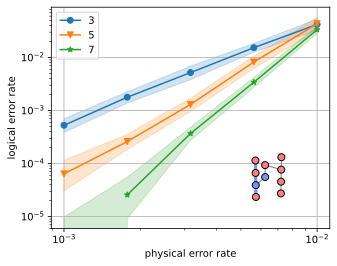

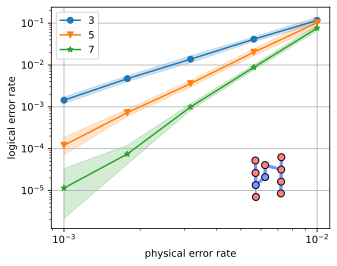

In [7]:
plot_stats(block_graph, mwpm_stats)
plt.show()

### Sliding window decoding

Practically speaking, decoding a monolothic block graph with MWPM is not scalable.  The sliding window decoder more closely resembles what would be used to decode during an actual quantum computation.  In short, a sliding window decoder chops up the block graph into "windows" that are decoded separately.  This method is known as the "overlapping recovery method" in [arXiv:quant-ph/0110143](https://arxiv.org/abs/quant-ph/0110143), which is explained more nicely in [arXiv:2012.15403](https://arxiv.org/abs/2012.15403) and [arXiv:2209.08552](https://arxiv.org/abs/2209.08552).  See also `help(decoders.SlidingWindowDecoder)`.

In [8]:
distances = [3, 5, 7]
sliding_window_decoders = [
    decoders.SlidingWindowDecoder(
        dist,  # decoding window size
        dist // 2,  # commit window size
        with_MWPM=True,
        decompose_errors=True,  # decomposes non-graphlike Y errors into independent X and Z errors
    )
    for dist in distances
]
sliding_window_stats = get_simulation_data(block_graph, distances, sliding_window_decoders)

Starting 16 workers...
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                  
        3       3 30m      99999         100 d=3,r=3,p=0.001                
        3       3   ?     100000         100 d=3,r=3,p=0.0017782794100389228
        3       3   ?     100000         100 d=3,r=3,p=0.0031622776601683794
        3       3   ?     100000         100 d=3,r=3,p=0.005623413251903491 
        4       3   ?     100000         100 d=3,r=3,p=0.01                 
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                  
        3       3 <1m      90237          91 d=3,r=3,p=0.001                
        3       3 <1m      94607          83 d=3,r=3,p=0.0017782794100389228
        3       3   ?     100000         100 d=3,r=3,p=0.0031622776601683794
        3       3 <1m      97679          39 d=3,r=3,p=0.005623413251903491 
        4       3 <1m      98839           3 d=3,r=3,p=0.01                 
5 tasks left:
  workers d

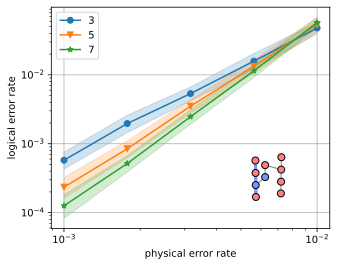

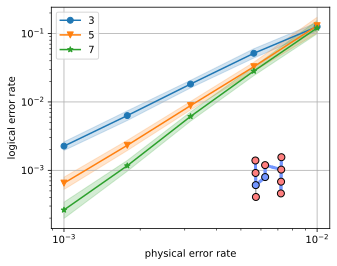

In [9]:
plot_stats(block_graph, sliding_window_stats)
plt.show()